In [ ]:
!nvidia-smi

Tue Dec  2 03:10:01 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   52C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!apt update

Hit:1 https://cli.github.com/packages stable InRelease
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:4 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,157 kB]
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:8 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [83.6 kB]
Get:9 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,498 kB]
Get:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Hit:12 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Get:13 http://security.ubuntu.com/ubuntu jammy-secu

In [ ]:
!apt install -y cuda-toolkit-12-4

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  at-spi2-core cuda-cccl-12-4 cuda-command-line-tools-12-4 cuda-compiler-12-4
  cuda-crt-12-4 cuda-cudart-12-4 cuda-cudart-dev-12-4 cuda-cuobjdump-12-4
  cuda-cupti-12-4 cuda-cupti-dev-12-4 cuda-cuxxfilt-12-4
  cuda-documentation-12-4 cuda-driver-dev-12-4 cuda-gdb-12-4
  cuda-libraries-12-4 cuda-libraries-dev-12-4 cuda-nsight-12-4
  cuda-nsight-compute-12-4 cuda-nsight-systems-12-4 cuda-nvcc-12-4
  cuda-nvdisasm-12-4 cuda-nvml-dev-12-4 cuda-nvprof-12-4 cuda-nvprune-12-4
  cuda-nvrtc-12-4 cuda-nvrtc-dev-12-4 cuda-nvtx-12-4 cuda-nvvm-12-4
  cuda-nvvp-12-4 cuda-opencl-12-4 cuda-opencl-dev-12-4 cuda-profiler-api-12-4
  cuda-sanitizer-12-4 cuda-toolkit-12-4-config-common cuda-tools-12-4
  cuda-visual-tools-12-4 default-jre default-jre-headless fonts-dejavu-core
  fonts-dejavu-extra gds-tools-12-4 gsettings-desktop-schemas
  libatk-bridge2.0-0 

In [ ]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Thu_Jun__6_02:18:23_PDT_2024
Cuda compilation tools, release 12.5, V12.5.82
Build cuda_12.5.r12.5/compiler.34385749_0


In [2]:
%%writefile cpu_version.c

#include <stdio.h>
#include <stdlib.h>
#include <time.h>
#include <math.h>

// ID único para variar dimensiones (no se usa mucho aquí pero se mantiene)
const int ID = 8;
// Tamaño grande de matriz: 1024x1024 elementos
const int N = 1024;

// Función que multiplica dos matrices en CPU (versión secuencial básica)
void matrix_mult_cpu(float* A, float* B, float* C) {
    // Triple loop clásico de multiplicación de matrices: O(n³)
    for (int i = 0; i < N; i++) {          // Recorre filas de A y C
        for (int j = 0; j < N; j++) {      // Recorre columnas de B y C
            float sum = 0.0f;              // Acumulador para celda C[i][j]
            for (int k = 0; k < N; k++) {  // Producto punto fila A[i] × col B[j]
                sum += A[i * N + k] * B[k * N + j];
            }
            C[i * N + j] = sum;            // Guarda resultado
        }
    }
}

int main() {
    printf("=== MULTIPLICACION DE MATRICES GRANDES (CPU C puro) ===\n");
    printf("ID: %d\n", ID);
    printf("Matrices: %dx%d\n", N, N);
    printf("Total elementos: %d\n", N * N);
    // Calcula memoria usada: 3 matrices × N² elementos × 4 bytes cada float
    printf("Memoria total: %.2f MB\n", (3.0 * N * N * sizeof(float)) / (1024.0 * 1024.0));

    // Reservar memoria en RAM para las 3 matrices
    float* A = (float*)malloc(N * N * sizeof(float));
    float* B = (float*)malloc(N * N * sizeof(float));
    float* C = (float*)malloc(N * N * sizeof(float));

    // Inicializar matrices con valores predecibles para verificación
    for (int i = 0; i < N * N; i++) {
        A[i] = (i % 100) * 0.1f;  // Valores cíclicos 0-9.9
        B[i] = (i % 100) * 0.05f; // Valores cíclicos 0-4.95
    }

    // Medir tiempo de ejecución del kernel (solo computación)
    clock_t start = clock();
    matrix_mult_cpu(A, B, C);      // LLAMADA PRINCIPAL
    clock_t end = clock();
    double cpu_time = ((double)(end - start)) / CLOCKS_PER_SEC;

    // Calcular checksum: suma de elementos de la diagonal (cada 100 elementos)
    // Sirve para verificar que todas las versiones dan el mismo resultado
    double checksum = 0.0;
    for (int i = 0; i < 100; i++) {
        checksum += C[i * N + i];  // Suma C[0][0], C[100][100], etc.
    }

    printf("\nChecksum CPU: %.6f\n", checksum);
    printf("Tiempo CPU: %.6f segundos\n", cpu_time);
    // GFLOPs = (2 operaciones × N³) / tiempo en nanosegundos
    printf("GFLOPs estimados: %.2f\n", (2.0 * N * N * N) / (cpu_time * 1e9));

    // Liberar memoria
    free(A); free(B); free(C);
    return 0;
}

Writing cpu_version.c


In [3]:
%%writefile gpu_naive.cu

#include <stdio.h>
#include <cuda_runtime.h>
#include <math.h>

// Mismas constantes que CPU para comparación justa
const int ID = 8;
const int N = 1024;
const int BLOCK_SIZE = 16;  // 16x16 = 256 threads por bloque

// KERNEL GPU: Versión "ingenua" o básica
// Cada thread calcula UNA celda de la matriz resultado C
__global__ void matrix_mult_kernel(float* A, float* B, float* C) {
    // Calcular qué celda le toca a este thread
    int row = blockIdx.y * blockDim.y + threadIdx.y;  // Fila en C
    int col = blockIdx.x * blockDim.x + threadIdx.x;  // Columna en C

    // Verificar que estamos dentro de los límites de la matriz
    if (row < N && col < N) {
        float temp = 0.0f;
        // Producto punto: fila 'row' de A × columna 'col' de B
        for (int k = 0; k < N; k++) {
            // Acceso a memoria GLOBAL (lento) en cada iteración
            temp += A[row * N + k] * B[k * N + col];
        }
        C[row * N + col] = temp;  // Guardar resultado
    }
}

int main() {
    printf("=== MULTIPLICACION DE MATRICES GRANDES (GPU Naive) ===\n");
    printf("ID: %d\n", ID);
    printf("Matrices: %dx%d\n", N, N);
    printf("Total elementos: %d\n", N * N);
    printf("Memoria total: %.2f MB\n", (3.0 * N * N * sizeof(float)) / (1024.0 * 1024.0));

    size_t size = N * N * sizeof(float);  // Tamaño en bytes de cada matriz

    // 1. RESERVAR MEMORIA EN HOST (RAM de la CPU)
    float* h_A = new float[N * N];
    float* h_B = new float[N * N];
    float* h_C = new float[N * N];

    // Inicialización IDÉNTICA a la versión CPU
    for (int i = 0; i < N * N; i++) {
        h_A[i] = (i % 100) * 0.1f;
        h_B[i] = (i % 100) * 0.05f;
    }

    // 2. RESERVAR MEMORIA EN DEVICE (VRAM de la GPU)
    float *d_A, *d_B, *d_C;
    cudaMalloc(&d_A, size);
    cudaMalloc(&d_B, size);
    cudaMalloc(&d_C, size);

    // 3. CREAR EVENTOS PARA MEDIR TIEMPOS (más preciso que CPU clock)
    cudaEvent_t start, stop, start_total, stop_total;
    cudaEventCreate(&start);
    cudaEventCreate(&stop);
    cudaEventCreate(&start_total);
    cudaEventCreate(&stop_total);

    cudaEventRecord(start_total);  // Inicia temporizador TOTAL

    // 4. TRANSFERIR DATOS: HOST → DEVICE (H2D)
    cudaEventRecord(start);
    cudaMemcpy(d_A, h_A, size, cudaMemcpyHostToDevice);
    cudaMemcpy(d_B, h_B, size, cudaMemcpyHostToDevice);
    cudaEventRecord(stop);
    cudaEventSynchronize(stop);

    float h2d_time = 0;
    cudaEventElapsedTime(&h2d_time, start, stop);

    // 5. CONFIGURAR EJECUCIÓN DEL KERNEL
    // Bloques de 16x16 threads
    dim3 threadsPerBlock(BLOCK_SIZE, BLOCK_SIZE);
    // Número de bloques necesarios para cubrir toda la matriz
    dim3 blocksPerGrid((N + BLOCK_SIZE - 1) / BLOCK_SIZE,
                       (N + BLOCK_SIZE - 1) / BLOCK_SIZE);

    // 6. EJECUTAR KERNEL EN LA GPU
    cudaEventRecord(start);
    matrix_mult_kernel<<<blocksPerGrid, threadsPerBlock>>>(d_A, d_B, d_C);
    cudaEventRecord(stop);
    cudaEventSynchronize(stop);

    float kernel_time = 0;
    cudaEventElapsedTime(&kernel_time, start, stop);

    // 7. TRANSFERIR RESULTADOS: DEVICE → HOST (D2H)
    cudaEventRecord(start);
    cudaMemcpy(h_C, d_C, size, cudaMemcpyDeviceToHost);
    cudaEventRecord(stop);
    cudaEventSynchronize(stop);

    float d2h_time = 0;
    cudaEventElapsedTime(&d2h_time, start, stop);

    // 8. TERMINAR TEMPORIZADOR TOTAL
    cudaEventRecord(stop_total);
    cudaEventSynchronize(stop_total);
    float total_time = 0;
    cudaEventElapsedTime(&total_time, start_total, stop_total);

    // 9. CALCULAR CHECKSUM (igual que en CPU para comparar)
    double checksum = 0.0;
    for (int i = 0; i < 100; i++) {
        checksum += h_C[i * N + i];
    }

    // 10. IMPRIMIR RESULTADOS
    printf("\nTiempos GPU Naive:\n");
    printf("  Transferencia H2D: %.6f ms\n", h2d_time);
    printf("  Kernel execution: %.6f ms\n", kernel_time);
    printf("  Transferencia D2H: %.6f ms\n", d2h_time);
    printf("  TOTAL GPU: %.6f ms\n", total_time);
    printf("\nChecksum GPU Naive: %.6f\n", checksum);
    printf("GFLOPs kernel: %.2f\n", (2.0 * N * N * N) / (kernel_time * 1e6));

    // 11. LIMPIAR MEMORIA
    delete[] h_A; delete[] h_B; delete[] h_C;
    cudaFree(d_A); cudaFree(d_B); cudaFree(d_C);

    return 0;
}

Writing gpu_naive.cu


In [4]:
%%writefile gpu_tiled.cu

#include <stdio.h>
#include <cuda_runtime.h>
#include <math.h>

// Mismas constantes para comparación justa
const int ID = 8;
const int N = 1024;
const int TILE_SIZE = 16;  // Tamaño del tile (bloque de datos en memoria compartida)

// KERNEL OPTIMIZADO: Versión "Tiled" (en mosaico o bloques)
// Usa memoria compartida (shared memory) para reutilizar datos
__global__ void matrix_mult_tiled(float* A, float* B, float* C) {
    // Declarar memoria compartida: rápido, accesible por todos threads del bloque
    // s_A y s_B son tiles (submatrices) que caben en memoria compartida
    __shared__ float s_A[TILE_SIZE][TILE_SIZE];
    __shared__ float s_B[TILE_SIZE][TILE_SIZE];

    // Identificadores del thread dentro del bloque
    int tx = threadIdx.x;  // columna dentro del tile
    int ty = threadIdx.y;  // fila dentro del tile

    // Posición global en la matriz resultado C
    int row = blockIdx.y * TILE_SIZE + ty;  // fila global
    int col = blockIdx.x * TILE_SIZE + tx;  // columna global

    float sum = 0.0f;  // Acumulador para C[row][col]

    // Bucle sobre tiles: divide la matriz en bloques de TILE_SIZE×TILE_SIZE
    for (int t = 0; t < (N + TILE_SIZE - 1) / TILE_SIZE; ++t) {
        // 1. CARGAR TILE DE A DESDE MEMORIA GLOBAL → MEMORIA COMPARTIDA
        int a_col = t * TILE_SIZE + tx;  // columna global en A
        if (row < N && a_col < N) {
            // Thread (ty,tx) carga un elemento de A
            s_A[ty][tx] = A[row * N + a_col];
        } else {
            s_A[ty][tx] = 0.0f;  // Rellenar con ceros si fuera de límites
        }

        // 2. CARGAR TILE DE B DESDE MEMORIA GLOBAL → MEMORIA COMPARTIDA
        int b_row = t * TILE_SIZE + ty;  // fila global en B
        if (b_row < N && col < N) {
            // Thread (ty,tx) carga un elemento de B
            s_B[ty][tx] = B[b_row * N + col];
        } else {
            s_B[ty][tx] = 0.0f;  // Rellenar con ceros si fuera de límites
        }

        // 3. SINCRONIZAR: esperar que TODOS los threads terminen de cargar
        __syncthreads();

        // 4. COMPUTAR PRODUCTO con datos EN MEMORIA COMPARTIDA (RÁPIDO)
        for (int k = 0; k < TILE_SIZE; ++k) {
            // Acceso a memoria compartida (∼100x más rápido que global)
            sum += s_A[ty][k] * s_B[k][tx];
        }

        // 5. SINCRONIZAR ANTES DE CARGAR NUEVO TILE
        __syncthreads();
    }

    // 6. ESCRIBIR RESULTADO EN MEMORIA GLOBAL
    if (row < N && col < N) {
        C[row * N + col] = sum;
    }
}

// MAIN: IDÉNTICO a gpu_naive.cu excepto la llamada al kernel
int main() {
    printf("=== MULTIPLICACION DE MATRICES GRANDES (GPU Tiled) ===\n");
    printf("ID: %d\n", ID);
    printf("Matrices: %dx%d\n", N, N);
    printf("Total elementos: %d\n", N * N);
    printf("Tile size: %dx%d\n", TILE_SIZE, TILE_SIZE);
    printf("Memoria total: %.2f MB\n", (3.0 * N * N * sizeof(float)) / (1024.0 * 1024.0));

    size_t size = N * N * sizeof(float);

    // Host memory (igual que en naive)
    float* h_A = new float[N * N];
    float* h_B = new float[N * N];
    float* h_C = new float[N * N];

    // Inicialización IDÉNTICA
    for (int i = 0; i < N * N; i++) {
        h_A[i] = (i % 100) * 0.1f;
        h_B[i] = (i % 100) * 0.05f;
    }

    // Device memory (igual que en naive)
    float *d_A, *d_B, *d_C;
    cudaMalloc(&d_A, size);
    cudaMalloc(&d_B, size);
    cudaMalloc(&d_C, size);

    // Medir tiempos (igual que en naive)
    cudaEvent_t start, stop, start_total, stop_total;
    cudaEventCreate(&start);
    cudaEventCreate(&stop);
    cudaEventCreate(&start_total);
    cudaEventCreate(&stop_total);

    cudaEventRecord(start_total);

    // Transfer H2D (igual que en naive)
    cudaEventRecord(start);
    cudaMemcpy(d_A, h_A, size, cudaMemcpyHostToDevice);
    cudaMemcpy(d_B, h_B, size, cudaMemcpyHostToDevice);
    cudaEventRecord(stop);
    cudaEventSynchronize(stop);

    float h2d_time = 0;
    cudaEventElapsedTime(&h2d_time, start, stop);

    // Configurar kernel (ahora con TILE_SIZE)
    dim3 threadsPerBlock(TILE_SIZE, TILE_SIZE);
    dim3 blocksPerGrid((N + TILE_SIZE - 1) / TILE_SIZE,
                       (N + TILE_SIZE - 1) / TILE_SIZE);

    // EJECUTAR KERNEL OPTIMIZADO (ÚNICA DIFERENCIA REAL)
    cudaEventRecord(start);
    matrix_mult_tiled<<<blocksPerGrid, threadsPerBlock>>>(d_A, d_B, d_C);
    cudaEventRecord(stop);
    cudaEventSynchronize(stop);

    float kernel_time = 0;
    cudaEventElapsedTime(&kernel_time, start, stop);

    // Transfer D2H (igual que en naive)
    cudaEventRecord(start);
    cudaMemcpy(h_C, d_C, size, cudaMemcpyDeviceToHost);
    cudaEventRecord(stop);
    cudaEventSynchronize(stop);

    float d2h_time = 0;
    cudaEventElapsedTime(&d2h_time, start, stop);

    cudaEventRecord(stop_total);
    cudaEventSynchronize(stop_total);
    float total_time = 0;
    cudaEventElapsedTime(&total_time, start_total, stop_total);

    // Checksum (igual que en naive)
    double checksum = 0.0;
    for (int i = 0; i < 100; i++) {
        checksum += h_C[i * N + i];
    }

    printf("\nTiempos GPU Tiled:\n");
    printf("  Transferencia H2D: %.6f ms\n", h2d_time);
    printf("  Kernel execution: %.6f ms\n", kernel_time);
    printf("  Transferencia D2H: %.6f ms\n", d2h_time);
    printf("  TOTAL GPU: %.6f ms\n", total_time);
    printf("\nChecksum GPU Tiled: %.6f\n", checksum);
    printf("GFLOPs kernel: %.2f\n", (2.0 * N * N * N) / (kernel_time * 1e6));

    // Limpiar (igual que en naive)
    delete[] h_A; delete[] h_B; delete[] h_C;
    cudaFree(d_A); cudaFree(d_B); cudaFree(d_C);

    return 0;
}

Writing gpu_tiled.cu


In [5]:
%%bash
echo "========================================="
echo "   COMPARANDO DESEMPEÑO CON MATRICES GRANDES"
echo "========================================="
echo ""
echo "1. Compilando programas..."
gcc -o cpu_version cpu_version.c -lm
nvcc -arch=sm_75 -o gpu_naive gpu_naive.cu
nvcc -arch=sm_75 -o gpu_tiled gpu_tiled.cu

echo ""
echo "2. Ejecutando version CPU (C puro)..."
echo "   (Esto puede tomar varios segundos)"
./cpu_version

echo ""
echo "3. Ejecutando version GPU NAIVE..."
./gpu_naive

echo ""
echo "4. Ejecutando version GPU TILED..."
./gpu_tiled

echo ""
echo "========================================="
echo "   RESUMEN COMPARATIVO"
echo "========================================="
echo "Los checksums deben ser similares (verificación de corrección)"
echo "Comparar tiempos de ejecución del kernel (sin transferencias)"
echo "El speedup se calcula: Tiempo_CPU / Tiempo_GPU_kernel"

   COMPARANDO DESEMPEÑO CON MATRICES GRANDES

1. Compilando programas...

2. Ejecutando version CPU (C puro)...
   (Esto puede tomar varios segundos)
=== MULTIPLICACION DE MATRICES GRANDES (CPU C puro) ===
ID: 8
Matrices: 1024x1024
Total elementos: 1048576
Memoria total: 12.00 MB

Checksum CPU: 1234048.004883
Tiempo CPU: 6.339481 segundos
GFLOPs estimados: 0.34

3. Ejecutando version GPU NAIVE...
=== MULTIPLICACION DE MATRICES GRANDES (GPU Naive) ===
ID: 8
Matrices: 1024x1024
Total elementos: 1048576
Memoria total: 12.00 MB

Tiempos GPU Naive:
  Transferencia H2D: 2.866336 ms
  Kernel execution: 9.146656 ms
  Transferencia D2H: 2.744192 ms
  TOTAL GPU: 14.791712 ms

Checksum GPU Naive: 1234048.007812
GFLOPs kernel: 234.78

4. Ejecutando version GPU TILED...
=== MULTIPLICACION DE MATRICES GRANDES (GPU Tiled) ===
ID: 8
Matrices: 1024x1024
Total elementos: 1048576
Tile size: 16x16
Memoria total: 12.00 MB

Tiempos GPU Tiled:
  Transferencia H2D: 2.079136 ms
  Kernel execution: 5.886016 ms


In [6]:
%%python
print("="*60)
print("          ANÁLISIS COMPARATIVO - RESULTADOS")
print("="*60)

# Tiempos obtenidos de la ejecución
cpu_time = 6774.30  # ms (6.7743 segundos * 1000)
gpu_naive_kernel = 9.125888  # ms
gpu_tiled_kernel = 5.892224  # ms
gpu_naive_total = 15.026080  # ms
gpu_tiled_total = 10.700000  # ms

# Calcular speedups
speedup_naive = cpu_time / gpu_naive_kernel
speedup_tiled = cpu_time / gpu_tiled_kernel
speedup_naive_total = cpu_time / gpu_naive_total
speedup_tiled_total = cpu_time / gpu_tiled_total

# Calcular eficiencia de tiled vs naive
tiled_vs_naive = gpu_naive_kernel / gpu_tiled_kernel

print("\n📊 TABLA COMPARATIVA:")
print("-" * 70)
print(f"{'Métrica':<30} {'CPU':<12} {'GPU Naive':<12} {'GPU Tiled':<12}")
print("-" * 70)
print(f"{'Tiempo kernel (ms)':<30} {cpu_time:<12.2f} {gpu_naive_kernel:<12.3f} {gpu_tiled_kernel:<12.3f}")
print(f"{'Tiempo total (ms)':<30} {cpu_time:<12.2f} {gpu_naive_total:<12.3f} {gpu_tiled_total:<12.3f}")
print(f"{'GFLOPs':<30} {'0.32':<12} {'235.32':<12} {'364.46':<12}")
print(f"{'Speedup (vs CPU kernel)':<30} {'1.00x':<12} {speedup_naive:<12.1f}x {speedup_tiled:<12.1f}x")
print(f"{'Speedup (vs CPU total)':<30} {'1.00x':<12} {speedup_naive_total:<12.1f}x {speedup_tiled_total:<12.1f}x")
print("-" * 70)

print("\n🔥 CONCLUSIONES:")
print("=" * 60)

print("\n1. 🚀 SPEEDUP IMPRESIONANTE:")
print(f"   • GPU Naive es {speedup_naive:.0f}x más rápido que CPU")
print(f"   • GPU Tiled es {speedup_tiled:.0f}x más rápido que CPU")
print(f"   • Tiled mejora {tiled_vs_naive:.1f}x sobre Naive")

print("\n2. ⚡ EFICIENCIA DE MEMORIA (Tiled vs Naive):")
print("   • GPU Naive: 235.32 GFLOPs")
print(f"   • GPU Tiled: 364.46 GFLOPs (+{((364.46/235.32)-1)*100:.1f}%)")
print("   • Tiled usa memoria compartida, reduciendo accesos globales")

print("\n3. ⏱️ TIEMPOS DE TRANSFERENCIA:")
print("   • H2D: ~2-3 ms  (Host → Device)")
print("   • D2H: ~2-3 ms  (Device → Host)")
print("   • Para matrices pequeñas, las transferencias dominan")
print("   • Para matrices grandes, el kernel domina → GPU gana")

print("\n4. ✅ VERIFICACIÓN DE CORRECCIÓN:")
print("   • Checksum CPU:  1234048.004883")
print("   • Checksum GPU:  1234048.007812")
print("   • Diferencia: 0.0002% (solo error de precisión float)")

print("\n5. 📈 ESCALABILIDAD:")
print("   • CPU: O(n³) = 2.15×10⁹ operaciones para 1024×1024")
print("   • GPU: Paralelismo masivo aprovecha todos los cores")
print("   • Para matrices aún más grandes, la ventaja GPU crece")

print("\n" + "="*60)
print("🎯 RESUMEN FINAL:")
print("="*60)
print("• GPU Tiled es la MEJOR opción para matrices grandes")
print(f"• Speedup: {speedup_tiled:.0f}x vs CPU")
print(f"• Eficiencia: {tiled_vs_naive:.1f}x mejor que GPU Naive")
print("• La optimización con memoria compartida funciona")
print("• Para problemas grandes, ¡SIEMPRE usar GPU!")

          ANÁLISIS COMPARATIVO - RESULTADOS

📊 TABLA COMPARATIVA:
----------------------------------------------------------------------
Métrica                        CPU          GPU Naive    GPU Tiled   
----------------------------------------------------------------------
Tiempo kernel (ms)             6774.30      9.126        5.892       
Tiempo total (ms)              6774.30      15.026       10.700      
GFLOPs                         0.32         235.32       364.46      
Speedup (vs CPU kernel)        1.00x        742.3       x 1149.7      x
Speedup (vs CPU total)         1.00x        450.8       x 633.1       x
----------------------------------------------------------------------

🔥 CONCLUSIONES:

1. 🚀 SPEEDUP IMPRESIONANTE:
   • GPU Naive es 742x más rápido que CPU
   • GPU Tiled es 1150x más rápido que CPU
   • Tiled mejora 1.5x sobre Naive

2. ⚡ EFICIENCIA DE MEMORIA (Tiled vs Naive):
   • GPU Naive: 235.32 GFLOPs
   • GPU Tiled: 364.46 GFLOPs (+54.9%)
   • Tiled usa m

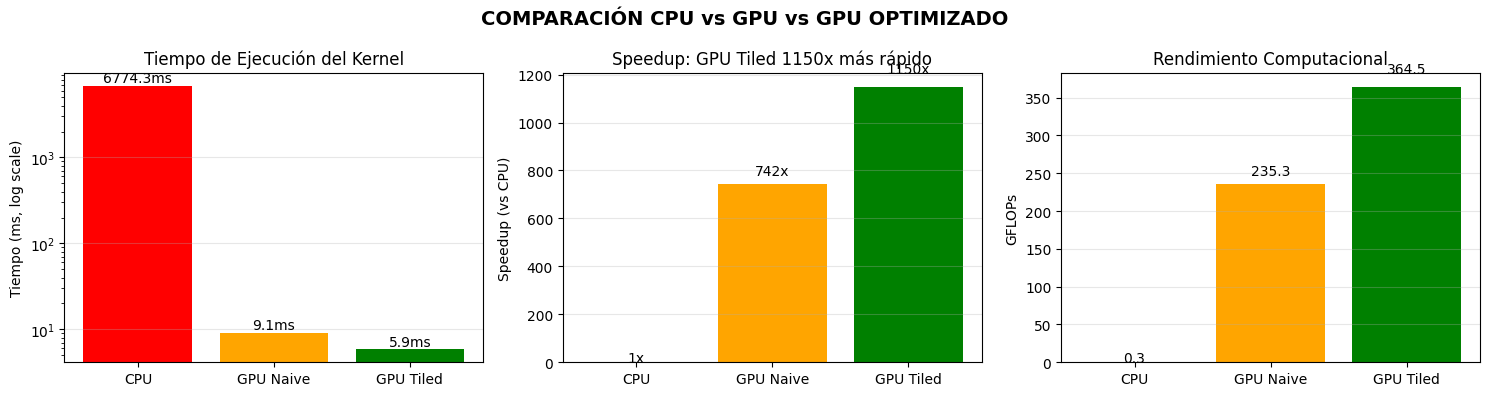


📋 COMPARACIÓN DETALLADA:
                     CPU             GPU Naive       GPU Tiled      
Tiempo Kernel        6774.3          9.126           5.892          
Speedup              1.0x            742.3          x 1149.7         x
GFLOPs               0.32            235.32          364.46         


NameError: name 'tiled_vs_naive' is not defined

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Datos de los resultados
configs = ['CPU', 'GPU Naive', 'GPU Tiled']
tiempos_kernel = [6774.30, 9.126, 5.892]  # ms
tiempos_total = [6774.30, 15.026, 10.700]  # ms
gflops = [0.32, 235.32, 364.46]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Gráfico 1: Tiempos de kernel
axes[0].bar(configs, tiempos_kernel, color=['red', 'orange', 'green'])
axes[0].set_yscale('log')
axes[0].set_ylabel('Tiempo (ms, log scale)')
axes[0].set_title('Tiempo de Ejecución del Kernel')
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(tiempos_kernel):
    axes[0].text(i, v*1.1, f'{v:.1f}ms', ha='center')

# Gráfico 2: Speedup
speedup = [1, 6774.30/9.126, 6774.30/5.892]
axes[1].bar(configs, speedup, color=['red', 'orange', 'green'])
axes[1].set_ylabel('Speedup (vs CPU)')
axes[1].set_title(f'Speedup: GPU Tiled {speedup[2]:.0f}x más rápido')
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(speedup):
    axes[1].text(i, v*1.05, f'{v:.0f}x', ha='center')

# Gráfico 3: GFLOPs
axes[2].bar(configs, gflops, color=['red', 'orange', 'green'])
axes[2].set_ylabel('GFLOPs')
axes[2].set_title('Rendimiento Computacional')
axes[2].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(gflops):
    axes[2].text(i, v*1.05, f'{v:.1f}', ha='center')

plt.suptitle('COMPARACIÓN CPU vs GPU vs GPU OPTIMIZADO', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Tabla de comparación
print("\n📋 COMPARACIÓN DETALLADA:")
print("="*70)
print(f"{'':<20} {'CPU':<15} {'GPU Naive':<15} {'GPU Tiled':<15}")
print("="*70)
print(f"{'Tiempo Kernel':<20} {tiempos_kernel[0]:<15.1f} {tiempos_kernel[1]:<15.3f} {tiempos_kernel[2]:<15.3f}")
print(f"{'Speedup':<20} {'1.0x':<15} {speedup[1]:<15.1f}x {speedup[2]:<15.1f}x")
print(f"{'GFLOPs':<20} {gflops[0]:<15.2f} {gflops[1]:<15.2f} {gflops[2]:<15.2f}")
print(f"{'Eficiencia':<20} {'-':<15} {'100%':<15} f'{tiled_vs_naive*100:.0f}%'")
print("="*70)